In [1]:
import h5py
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import string
from astropy.cosmology import Planck18 as cosmo

In [32]:
# Record the mass of dm and gas of the subhalo

models = [model for model in os.listdir('./') if (model[2] == '_')]

record_name = np.zeros( len(models) )
record_set = np.zeros( (len(models), 4) )

for j, dir in enumerate(models):

    name = dir.split('_')[1][7:]
    # jump the directory which has been skipped
    if dir[-1] != 'a':
        continue
    print(dir)
    files = [file for file in os.listdir('./'+dir) if file.endswith('.hdf5')]
    
    find = 0
    if 'gas_merge.hdf5' in files:
        f = h5py.File( dir + '/gas_merge.hdf5' )
        find = 1
    elif 'TNG_modified.hdf5' in files:
        f = h5py.File( dir + '/TNG_modified.hdf5' )
        find = 1
    else:
        for file_i in files:
            if 'modified' in file_i:
                f = h5py.File( dir + '/' + file_i )
                find = 1
                break
        if find == 0:
            print("Error! no hdf5 file in the directory")
            print(name)
    
    # Record the mass of dm and gas of the subhalo
    if find == 0:
        continue
    
    record_name[j] = int(name)

    gas_mass = np.sum( f['PartType0']['Masses'][:] ) * 1e10 / 0.6774
    dm_mass = np.sum( f['PartType1']['Masses'][:] ) * 1e10 / 0.6774
    
    gas_coord = f['PartType0']['Coordinates'][:]
    dm_coord = f['PartType1']['Coordinates'][:]

    scale_factor        = f['Header'].attrs['Time']
    unit_length_cgs     = f['Header'].attrs['UnitLength_In_CGS']
    unit_mass_cgs       = f['Header'].attrs['UnitMass_In_CGS']
    unit_vel_cgs        = f['Header'].attrs['UnitVelocity_In_CGS']

    # Find the coordinate range of the particles
    min_set = np.zeros(3)
    max_set = np.zeros(3)

    for i in range(3):
        min_set[i] = min( np.min(gas_coord[:,i]), np.min(dm_coord[:,i]) )
        max_set[i] = max( np.max(gas_coord[:,i]), np.max(dm_coord[:,i]) )

    range_len = np.max(max_set - min_set)
    
    record_set[j, 0] = gas_mass
    record_set[j, 1] = dm_mass
    record_set[j, 2] = gas_mass + dm_mass

    # Record the last snapshot of the models
    output_files = [file for file in os.listdir('./'+dir+'/output') if file.endswith('.hdf5')]
    # Record the largest number of snapshot
    largest = 0
    for file_i in output_files:
        if int(file_i[9:12]) > largest:
            largest = int(file_i[9:12])

    record_set[j, 3] = largest


03_subhalo28585_a
08_subhalo28117_a
18_subhalo29124_a
09_subhalo31901_a
15_subhalo31859_a
07_subhalo23715_a
16_subhalo31887_a
01_subhalo27261_a
04_subhalo31708_a
19_subhalo33119_a
00_subhalo32896_a
20_subhalo33049_a
10_subhalo28597_a
02_subhalo33078_a
12_subhalo32591_a


In [34]:
# For the normal record
f = open('record_mass.csv', 'w')

# write the file according to the rank of the mass
sort_idx = np.argsort(record_set[:,1])
i = 0

f.write('Subhalo ID,Gas Mass,DM Mass,Total Mass,Last snapshot' + '\n')
for ind in sort_idx:
    if record_name[ind] != 0:
        # f.write( '%s & %.2f & %.2f & %.2f & %.2f \\\\ \n' % (str(int(record_name[ind])), record_set[ind, 0], record_set[ind, 1], record_set[ind, 2], record_set[ind, 3]) )
        f.write( '%s,%.4f,%.4f,%.4f,%d\n' % (str(int(record_name[ind])), record_set[ind, 0], record_set[ind, 1], record_set[ind, 2], record_set[ind, 3]) )
        i += 1

f.close()

In [8]:
# For overleaf

f = open('record_mass_2.csv', 'w')

# write the file according to the rank of the mass
sort_idx = np.argsort(record_set[:,2])

record_set /= 1e5
i = 0
f.write('Index,Subhalo ID,Gas Mass,DM Mass,Total Mass' + '\n')
for ind in sort_idx:
    if record_name[ind] != 0:
        # f.write( '%s,%.2f,%.2f,%.2f,%.2f' % (str(int(record_name[ind,1])), record_set[ind, 0], record_set[ind, 1], record_set[ind, 2], record_set[ind, 3]) + '\n' )
        f.write( '%s & %s & %.2f & %.2f & %.2f \\\\' % (string.ascii_uppercase[i], str(int(record_name[ind])), record_set[ind, 0], record_set[ind, 1], record_set[ind, 2]) + '\n' )
        i += 1

f.close()

In [ ]:
# Run the k spectrum script in every valid model directory
models = [model for model in os.listdir('./') if (model[2] == '_')]

# multiprocessing
import multiprocessing

def run_script(dir):
    # jump the directory which has been skipped
    if dir[-1] != 'a':
        return
    
    dir_output = dir + '/output/'

    # copy the script to the directory
    os.system('cp k_spectrum.py ' + dir_output)
    # execute the script
    os.system('cd ' + dir_output + ' && rm record.txt && python3 k_spectrum.py')

    # return back to the current directory
    os.system('cd ../../')

pool = multiprocessing.Pool(processes=4)
pool.map(run_script, models)
pool.close()
pool.join()

In [2]:
# checkout which models hasn't ran successfully
models = [model for model in os.listdir('./') if (model[2] == '_')]

for dir in models:
    dir_output = dir + '/output/'
    # if not os.path.exists(dir_output + 'spectrum_008.txt'):
    if os.path.exists(dir_output + 'record.txt'):
        print(dir)

03_subhalo28585_a
08_subhalo28117_a
18_subhalo29124_a
09_subhalo31901_a
15_subhalo31859_a
07_subhalo23715_a
16_subhalo31887_a
01_subhalo27261_a
04_subhalo31708_a
19_subhalo33119_a
00_subhalo32896_a
20_subhalo33049_a
10_subhalo28597_a
02_subhalo33078_a
12_subhalo32591_a


In [3]:
# Run the mach_number script in every valid model directory
models = [model for model in os.listdir('./') if (model[2] == '_')]

for dir in models:
    # jump the directory which has been skipped
    if dir[-1] != 'a':
        continue

    print(dir)
    dir_output = dir + '/output/'

    # # clean the old data
    # os.system('rm ' + dir_output + 'mach_number_054*.txt')
    # os.system('rm ' + dir_output + 'mach_number*.py')
    if os.path.exists(dir_output + "spectrum_combined.txt"):
        os.system('rm ' + dir_output + 'spectrum_combined.txt')

    # copy the script to the directory
    os.system('cp k_spectrum.py ' + dir_output)
    # execute the script
    os.system('cd ' + dir_output + ' && python3 k_spectrum.py')

    # return back to the current directory
    os.system('cd ../../')

03_subhalo28585_a


08_subhalo28117_a
18_subhalo29124_a
09_subhalo31901_a
15_subhalo31859_a
07_subhalo23715_a
16_subhalo31887_a
01_subhalo27261_a
04_subhalo31708_a
19_subhalo33119_a
00_subhalo32896_a
20_subhalo33049_a
10_subhalo28597_a
02_subhalo33078_a
12_subhalo32591_a


In [9]:
f = pd.read_csv('record_mass.csv')
f

,Subhalo ID,Gas Mass,DM Mass,Total Mass,Last snapshot
0,33119,1.384222e+06,6.806192e+06,8.190415e+06,74
1,33049,1.342821e+06,7.259940e+06,8.602761e+06,79
2,32591,1.393140e+06,7.713686e+06,9.106826e+06,71
3,29124,1.491985e+06,7.713686e+06,9.205671e+06,90
4,31901,1.377141e+06,7.713686e+06,9.090827e+06,64
5,31859,1.259895e+06,7.713686e+06,8.973581e+06,66
6,33078,1.305032e+06,7.713686e+06,9.018719e+06,56
7,32896,1.323538e+06,7.713686e+06,9.037225e+06,54
8,28585,1.421934e+06,8.167433e+06,9.589367e+06,65
9,31708,1.142326e+06,8.167433e+06,9.309759e+06,78


In [ ]:
# Make the combined csv file

models = [model for model in os.listdir('./') if (model[2] == '_')]
model_num = len(f['Subhalo ID'])

# dimension 0: models, dimension1: density beams, dimension2: mach number and mach number std
record = np.zeros( (model_num, 2) )
virial_raidus = np.zeros( model_num )
virial_mass = np.zeros( model_num )
virial_mass_gas = np.zeros( model_num )
virial_mass_dm = np.zeros( model_num )
time = np.zeros( model_num )
redshift = np.zeros( model_num )

for dir in models:
    # jump the directory which has been skipped
    if dir[-1] != 'a':
        continue

    name = int(dir.split('_')[1][7:])

    # locate the rows
    record_ind = np.where(f['Subhalo ID'] == name)[0][0]

    snapshot_ind = f['Last snapshot'][record_ind]
    # snapshot_ind = 54

    dir_output = dir + '/output/mach_number_%03d_radius.txt' % snapshot_ind
    # record the file's info
    file = open(dir_output, 'r')
    lines = file.readlines()
    
    data = lines[1].split(',')
    virial_raidus[record_ind] = float(data[2])
    virial_mass[record_ind] = float(data[3])
    virial_mass_gas[record_ind] = float(data[4])
    virial_mass_dm[record_ind] = float(data[5])
    time[record_ind] = (cosmo.age(float(data[6])).value - cosmo.age(20).value) * 1e3
    redshift[record_ind] = float(data[6])

    file.close()

# combinde the data with the original csv file

f['Virial Radius'] = virial_raidus
f['Virial Mass'] = virial_mass
# f['Gas Mass'] = virial_mass_gas
# f['DM Mass'] = virial_mass_dm
f['z'] = redshift

# sort the record according to the virial mass

sort_idx = np.argsort(virial_mass)
f1 = open('record_mass_combined.csv', 'w')

f1.write('Model,Subhalo ID,Gas Mass,DM Mass,Total Mass,Virial Radius,Virial Mass,Virial Gas Mass,Virial DM Mass,Last snapshot,z,Time' + '\n')

i = 0
for ind in sort_idx:
    if f['Subhalo ID'][ind] != 0:
        f1.write( '%s,%s,%.2f,%.2f,%.2f,%.2f,%.2f,%.2f,%.2f,%d,%.2f,%.2f' % (string.ascii_uppercase[i], str(int(f['Subhalo ID'][ind])), f['Gas Mass'][ind], f['DM Mass'][ind], f['Total Mass'][ind], 
                                                      virial_raidus[ind], virial_mass[ind], virial_mass_gas[ind], virial_mass_dm[ind], f['Last snapshot'][ind], f['z'][ind], time[ind]) + '\n' )
        i += 1

f1.close()

In [11]:
f = pd.read_csv('record_mass_combined.csv')
f

,Model,Subhalo ID,Gas Mass,DM Mass,Total Mass,Virial Radius,Virial Mass,Virial Gas Mass,Virial DM Mass,Last snapshot,z,Time
0,A,28585,1421934.47,8167432.77,9589367.24,121.79,489906.9,61861.16,428045.8,65,18.74,17.41
1,B,31859,1259895.22,7713686.27,8973581.49,133.74,636624.9,87166.56,549458.3,66,18.72,17.71
2,C,33119,1384222.36,6806192.40,8190414.77,162.23,1110456.0,137715.20,972740.6,74,18.57,19.97
3,D,23715,1711566.24,9074925.78,10786492.02,161.42,1153792.0,115581.20,1038210.0,69,18.66,18.61
4,E,29124,1491984.52,7713686.27,9205670.79,180.83,1401261.0,143045.70,1258215.0,90,18.26,24.80
5,F,28117,1547454.94,8621179.28,10168634.22,196.59,1890009.0,175166.80,1714842.0,81,18.43,22.13
6,G,31901,1377141.14,7713686.27,9090827.41,202.43,2253925.0,218380.80,2035544.0,64,18.76,17.11
7,H,27261,1491146.40,8621179.28,10112325.67,213.30,2542729.0,274330.20,2268399.0,70,18.64,18.91
8,I,31887,1273019.33,8167432.77,9440452.11,219.86,2850546.0,281163.60,2569382.0,54,18.96,14.17
9,J,33078,1305032.26,7713686.27,9018718.53,253.11,3080805.0,297611.60,2783194.0,56,18.92,14.75


In [12]:
# For overleaf

f1 = open('record_mass_combined_2.csv', 'w')

# write the file according to the rank of the mass
# sort_idx = np.argsort(virial_mass)

f1.write('Halo, Virial Radius, Virial Mass, Gas Mass, DM Mass, Time[Myr]' + '\n')

virial_mass = f['Virial Mass'] / 1e5
virial_mass_gas = f['Virial Gas Mass'] / 1e5
virial_mass_dm = f['Virial DM Mass'] / 1e5

# for i in sort_idx:
#     if f['Subhalo ID'][ind] != 0:
#         f1.write( '%s & %.2f & %.2f \\\\' % (f['Model'][ind], virial_raidus[ind], virial_mass[ind]) + '\n' )

for i in range(len(f['Model'])):
    f1.write( '\\textbf{%s} & %.2f & %.2f & %.2f & %.2f & %.2f \\\\' % (f['Model'][i], f['Virial Radius'][i], 
                                                  virial_mass[i], virial_mass_gas[i], virial_mass_dm[i], f['Time'][i]) + '\n' )

f1.close()

Run the analysis

In [15]:
# Record the mass and the density of the gas in the subhalo
f = pd.read_csv('record_mass_combined.csv')
f

,Model,Subhalo ID,Gas Mass,DM Mass,Total Mass,Virial Radius,Virial Mass,Virial Gas Mass,Virial DM Mass,Last snapshot,z,Time
0,A,28585,1421934.47,8167432.77,9589367.24,121.79,489906.9,61861.16,428045.8,65,18.74,17.41
1,B,31859,1259895.22,7713686.27,8973581.49,133.74,636624.9,87166.56,549458.3,66,18.72,17.71
2,C,33119,1384222.36,6806192.40,8190414.77,162.23,1110456.0,137715.20,972740.6,74,18.57,19.97
3,D,23715,1711566.24,9074925.78,10786492.02,161.42,1153792.0,115581.20,1038210.0,69,18.66,18.61
4,E,29124,1491984.52,7713686.27,9205670.79,180.83,1401261.0,143045.70,1258215.0,90,18.26,24.80
5,F,28117,1547454.94,8621179.28,10168634.22,196.59,1890009.0,175166.80,1714842.0,81,18.43,22.13
6,G,31901,1377141.14,7713686.27,9090827.41,202.43,2253925.0,218380.80,2035544.0,64,18.76,17.11
7,H,27261,1491146.40,8621179.28,10112325.67,213.30,2542729.0,274330.20,2268399.0,70,18.64,18.91
8,I,31887,1273019.33,8167432.77,9440452.11,219.86,2850546.0,281163.60,2569382.0,54,18.96,14.17
9,J,33078,1305032.26,7713686.27,9018718.53,253.11,3080805.0,297611.60,2783194.0,56,18.92,14.75


In [26]:
# Record the mach_number in every valid model directory
models = [model for model in os.listdir('./') if (model[2] == '_')]
model_num = len(f['Subhalo ID'])

mach = np.zeros( len(models) )
mach_std = np.zeros( len(models) )

virial_radius = np.zeros( len(models) )
virial_mass = np.zeros( len(models) )

for dir in models:
    # find the corresponding ID
    # jump the directory which has been skipped
    if dir[-1] != 'a':
        continue

    ID = int(dir.split('_')[1][7:])
    idx = np.where(f['Subhalo ID'] == ID)[0][0]

    snapshot_ind = f['Last snapshot'][idx]
    # snapshot_ind = 54

    dir_output = dir + '/output/mach_number_%03d_radius.txt' % snapshot_ind
    # record the file's info
    file = open(dir_output, 'r')
    lines = file.readlines()
    file.close()
    
    # record the mach number
    line_data = lines[1].split(',')
    mach[idx] = float(line_data[0])
    mach_std[idx] = float(line_data[1])

    # record the virial mass and virial radius
    virial_radius[idx] = float(line_data[2])
    virial_mass[idx] = float(line_data[3])

In [4]:
from astropy.cosmology import Planck18 as cosmo
density_threshold = 200*cosmo.critical_density(18.96).value

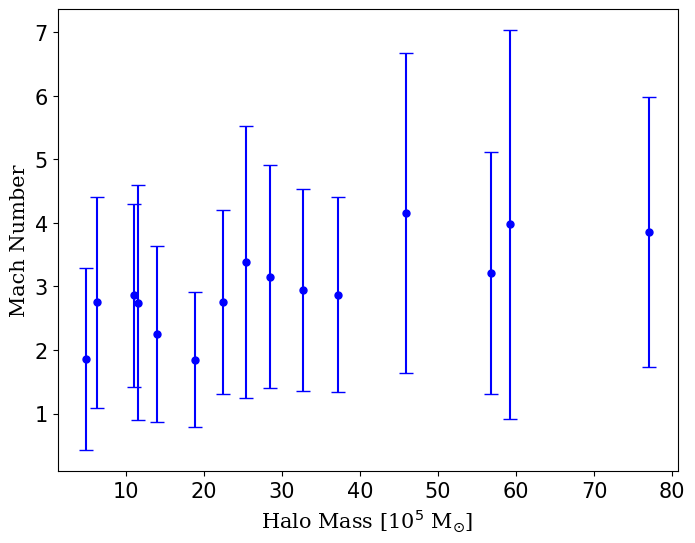

In [5]:
# plot the relation between the DM mass and the mach number

font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

plt.figure(figsize=(8,6))
plt.errorbar(virial_mass[:model_num] / 1e5, mach[:model_num], yerr=mach_std[:model_num], fmt='o', markersize=5, capsize=5, capthick=1, color='blue')

x_lim_min = 5.50
x_lim_max = 7.30
# plt.text((x_lim_min*1+x_lim_max*4)/5, 4.5, r"$\rho$ > $\rho_{200,c}$", fontdict=font)
plt.xlabel('Halo Mass [10$^5$ M$_{\odot}$]', fontdict=font)
plt.ylabel('Mach Number', fontdict=font)
plt.xticks( fontsize=15 )
plt.yticks( fontsize=15 )

# plt.title('Mach Number to Halo Mass', fontdict=font)
# plt.ylim(0, 3)
# plt.xlim(x_lim_min, x_lim_max)

# plt.savefig('mach_number.png', dpi=500)
plt.show()

In [6]:
# Do line fitting?

from scipy.optimize import curve_fit

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, virial_mass[:model_num], mach[:model_num])

popt


array([2.45816034e-07, 2.23330161e+00])

In [ ]:
# plot the relation between the DM mass and the mach number

font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

plt.figure(figsize=(8,6), dpi=200)
plt.errorbar(virial_mass[:model_num] / 1e5, mach[:model_num], yerr=mach_std[:model_num], fmt='o', markersize=5, capsize=5, capthick=1, color='blue')

x_lim_min = 5.50
x_lim_max = 7.30
# plt.text((x_lim_min*1+x_lim_max*4)/5, 4.5, r"$\rho$ > $\rho_{200,c}$", fontdict=font)
plt.xlabel('Halo Mass [10$^5$ M$_{\odot}$]', fontdict=font)
plt.ylabel('Mach Number', fontdict=font)
plt.xticks( fontsize=15 )
plt.yticks( fontsize=15 )
plt.plot(virial_mass[:model_num] / 1e5, func(virial_mass[:model_num], *popt), color='red', label='y=%.2ex+%5.2f' % tuple(popt))

# plt.legend(fontsize=15)

# plt.title('Mach Number to Halo Mass', fontdict=font)
# plt.ylim(0, 3)
# plt.xlim(x_lim_min, x_lim_max)

# plt.savefig('mach_number.png', dpi=500)
plt.show()

In [12]:
max(mach[:model_num]), min(mach[:model_num])

(4.1563, 1.8471)

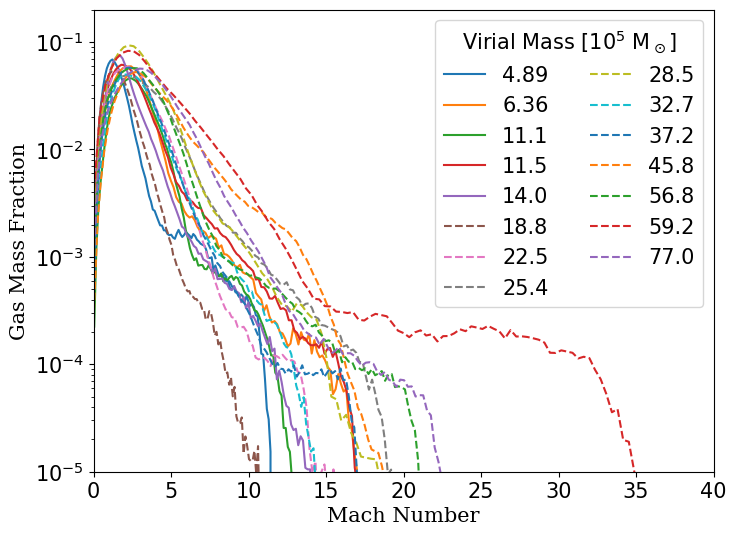

In [44]:
# Record the mach_number curve in every valid model directory

models = [model for model in os.listdir('./') if (model[2] == '_')]
model_id = [int(model[10:15]) for model in models]
beams = np.logspace(-23, -13, 100)

font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

Number_Density_Fraction = 1.16e-24
density = np.zeros( len(models) )
mach = np.zeros( len(models) )
mach_std = np.zeros( len(models) )
legend = []

plt.figure(figsize=(8,6))
for ind, dir in enumerate(f['Subhalo ID']):

    dir_idx = np.where(np.array(model_id) == dir)[0][0]
    dir = models[dir_idx]

    # snapshot_ind = 54

    # jump the directory which has been skipped
    if dir[-1] != 'a':
        continue
    dir_output = dir + '/output/mach_number_%03d_curve.txt' % f['Last snapshot'][ind]
    # record the file's info
    file = open(dir_output, 'r')
    lines = file.readlines()
    file.close()

    # record the mach number
    mach = np.zeros( len(lines)-1 )
    mass = np.zeros( len(lines)-1 )

    for i in range(1, len(lines)):
        line = lines[i].split(',')
        mach[i-1] = float(line[0])
        mass[i-1] = float(line[1])
    
    # plot the mach number curve
    if ind < 5:
        plt.plot( mach, mass / np.sum(mass), alpha=1)
    else:
        plt.plot( mach, mass / np.sum(mass), alpha=1, linestyle='--')

    
    legend.append( int(f['Virial Mass'][ind] / 1e3) ) 
    
# Legends for 2 columns
legend = np.array( legend ) /1e2 
for ind, val in enumerate(legend):
    if val > 10:
        legend[ind] = val * 100 // 10 / 10
plt.legend( legend, loc='upper right', title='Virial Mass [10$^5$ M$_\odot$]', fontsize=15, title_fontsize=15, ncol=2)

plt.xlabel('Mach Number', fontdict=font)
plt.ylabel('Gas Mass Fraction', fontdict=font)
plt.xticks( fontsize=15 )
plt.yticks( fontsize=15 )

plt.ylim(1e-5, 2e-1)
plt.xlim(0, 40)
plt.yscale('log')

plt.show()

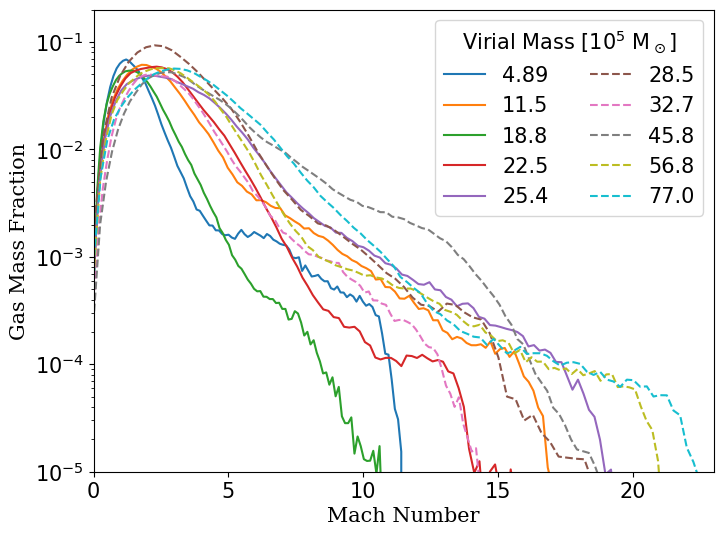

In [31]:
# For Ch3_5_turb3
# Record the mach_number curve in every valid model directory

models = [model for model in os.listdir('./') if (model[2] == '_')]
model_id = [int(model[10:15]) for model in models]
beams = np.logspace(-23, -13, 100)

font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

Number_Density_Fraction = 1.16e-24
density = np.zeros( len(models) )
mach = np.zeros( len(models) )
mach_std = np.zeros( len(models) )
legend = []

halo_list= [ 0, 3, 5, 6, 7, 8, 10, 12, 13, 14]
halo_id_list = [ f['Subhalo ID'][ind] for ind in halo_list ]
snapshot_ind_list = [ f['Last snapshot'][ind] for ind in halo_list ]

plt.figure(figsize=(8,6))
for ind, dir in enumerate(halo_id_list):

    dir_idx = np.where(model_id == dir)[0][0]
    dir = models[dir_idx]

    # snapshot_ind = 54

    # jump the directory which has been skipped
    if dir[-1] != 'a':
        continue
    dir_output = dir + '/output/mach_number_%03d_curve.txt' % snapshot_ind_list[ind]
    # record the file's info
    file = open(dir_output, 'r')
    lines = file.readlines()
    file.close()

    # record the mach number
    mach = np.zeros( len(lines)-1 )
    mass = np.zeros( len(lines)-1 )

    for i in range(1, len(lines)):
        line = lines[i].split(',')
        mach[i-1] = float(line[0])
        mass[i-1] = float(line[1])
    
    # plot the mach number curve
    if ind < 5:
        plt.plot( mach, mass / np.sum(mass), alpha=1)
    else:
        plt.plot( mach, mass / np.sum(mass), alpha=1, linestyle='--')

    
    legend.append( int(f['Virial Mass'][halo_list[ind]] / 1e3) ) 
    
# Legends for 2 columns
legend = np.array( legend ) /1e2 
for ind, val in enumerate(legend):
    if val > 10:
        legend[ind] = val * 100 // 10 / 10
plt.legend( legend, loc='upper right', title='Virial Mass [10$^5$ M$_\odot$]', fontsize=15, title_fontsize=15, ncol=2)

plt.xlabel('Mach Number', fontdict=font)
plt.ylabel('Gas Mass Fraction', fontdict=font)
plt.xticks( fontsize=15 )
plt.yticks( fontsize=15 )

plt.ylim(1e-5, 2e-1)
plt.xlim(0, 23)
plt.yscale('log')

plt.show()

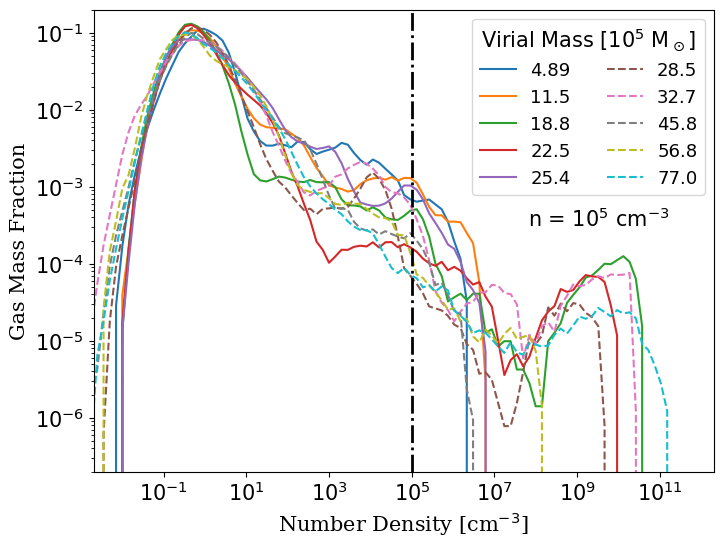

In [28]:
# Ch3_5_turb4
# Record the density to mass curve in every valid model directory

models = [model for model in os.listdir('./') if (model[2] == '_')]
model_id = [int(model[10:15]) for model in models]
beams = np.logspace(-23, -10, 100)

font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

Number_Density_Fraction = 1.16e-24
density = np.zeros( len(models) )
mach = np.zeros( len(models) )
mach_std = np.zeros( len(models) )
legend = []

halo_list= [ 0, 3, 5, 6, 7, 8, 10, 12, 13, 14]
halo_id_list = [ f['Subhalo ID'][ind] for ind in halo_list ]
snapshot_ind_list = [ f['Last snapshot'][ind] for ind in halo_list ]

plt.figure(figsize=(8,6))
for ind, dir in enumerate(halo_id_list):

    dir_idx = np.where(model_id == dir)[0][0]
    dir = models[dir_idx]

    # jump the directory which has been skipped
    if dir[-1] != 'a':
        continue
    dir_output = dir + '/output/mach_number_%03d_curve_density.txt' % snapshot_ind_list[ind]
    # record the file's info
    file = open(dir_output, 'r')
    lines = file.readlines()
    file.close()

    # record the mach number
    density = np.zeros( len(lines)-1 )
    mass = np.zeros( len(lines)-1 )

    for i in range(1, len(lines)):
        line = lines[i].split(',')
        density[i-1] = float(line[0])
        mass[i-1] = float(line[1])

    # Convert to number density
    density /= Number_Density_Fraction
    
    # plot the mach number curve
    if ind < 5:
        plt.plot( density, mass / np.sum(mass), alpha=1)
    else:
        plt.plot( density, mass / np.sum(mass), alpha=1, linestyle='--')

    
    legend.append( int(f['Virial Mass'][halo_list[ind]] / 1e3) ) 
    
# Legends for 2 columns
legend = np.array( legend ) /1e2 
for ind, val in enumerate(legend):
    if val > 10:
        legend[ind] = val * 100 // 10 / 10
plt.legend( legend, loc='upper right', title='Virial Mass [10$^5$ M$_\odot$]', fontsize=13, title_fontsize=15, ncol=2)

plt.xlabel('Number Density [cm$^{-3}$]', fontdict=font)
plt.ylabel('Gas Mass Fraction', fontdict=font)
plt.xticks( fontsize=15 )
plt.yticks( fontsize=15 )

# Plot a vertical line at 1e4 cm^-3
plt.axvline(1e5, color='black', linestyle='-.', linewidth=2.0)
# Label it
plt.text(0.7, 0.53, 'n = 10$^5$ cm$^{-3}$', fontsize=15, transform=plt.gca().transAxes)

plt.ylim(2e-7, 2e-1)
plt.xlim(2e-3, 2e12)
plt.yscale('log')
plt.xscale('log')

plt.show()

yt : [INFO     ] 2025-02-13 09:35:58,173 Omega Lambda is 0.0, so we are turning off Cosmology.
yt : [INFO     ] 2025-02-13 09:35:58,202 Parameters: current_time              = 0.050652481190752614
yt : [INFO     ] 2025-02-13 09:35:58,202 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-02-13 09:35:58,203 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-13 09:35:58,203 Parameters: domain_right_edge         = [30. 30. 30.]
yt : [INFO     ] 2025-02-13 09:35:58,204 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-13 09:35:58,227 Allocating for 7.151e+06 particles
Loading particle index: 100%|██████████| 27/27 [00:00<00:00, 25743.63it/s]
yt : [INFO     ] 2025-02-13 09:36:00,373 Omega Lambda is 0.0, so we are turning off Cosmology.
yt : [INFO     ] 2025-02-13 09:36:00,404 Parameters: current_time              = 0.05090625062829638
yt : [INFO     ] 2025-02-13 09:36:00,404 Parameters: domain_dimensions         = [1 1 1]
yt : [IN

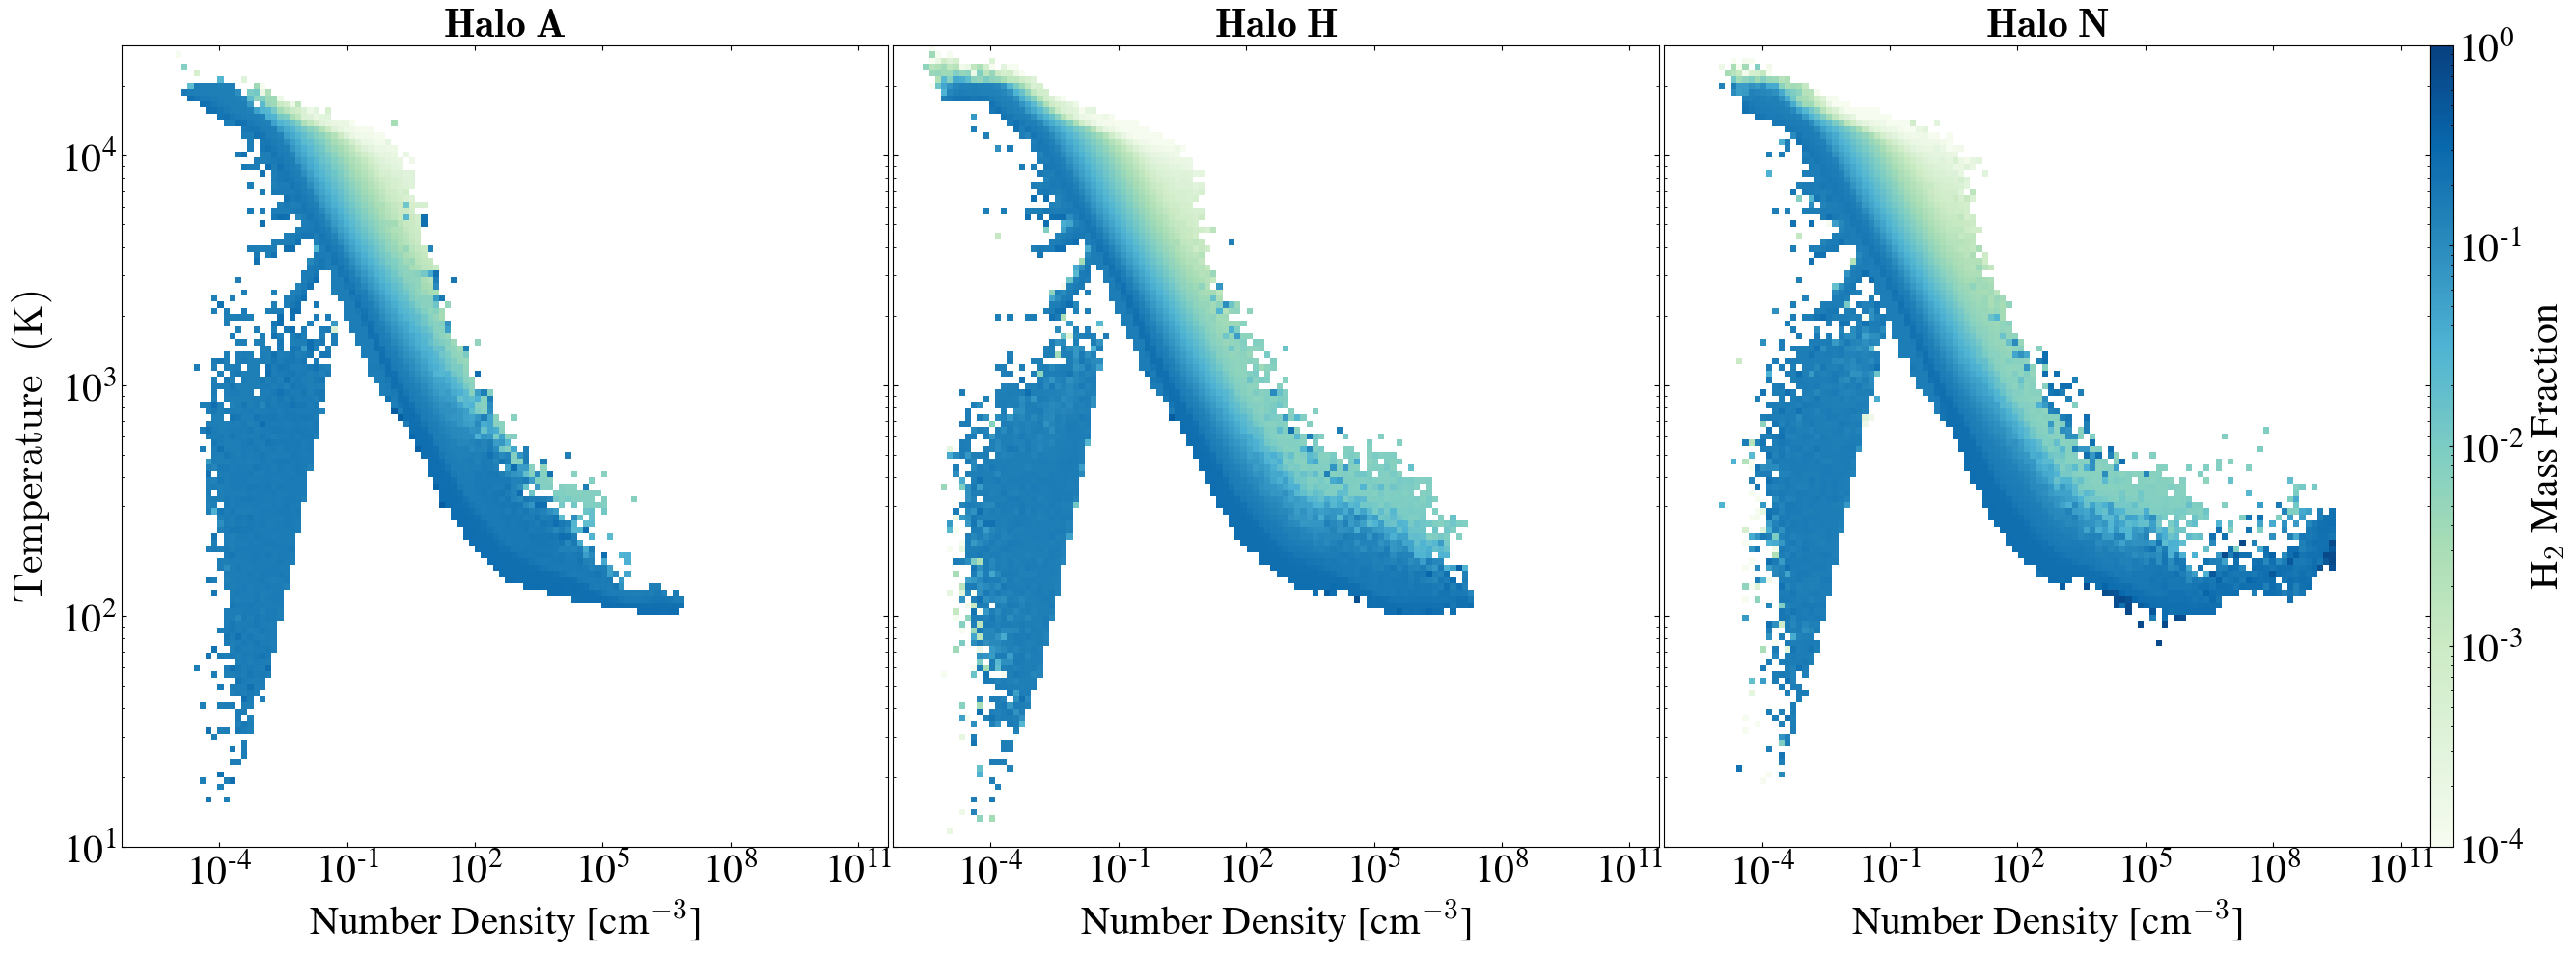

In [7]:
# Ch3_3 pictures

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid

import yt

f = ["03_subhalo28585_a/output/snapshot_065.hdf5",
    "01_subhalo27261_a/output/snapshot_070.hdf5",
    "02_subhalo33078_a/output/snapshot_056.hdf5"]

Halo_list = ['A', 'H', 'N']

scale_factor = 0.050098632525354785
unit_length_cgs = 3.08567758e21
unit_mass_cgs = 1.989e43
Number_Density_Fraction = 1.16e-24

unit_base = {
    "length": (scale_factor * unit_length_cgs / 3.08e21, "kpc"),
    "velocity": (1.0, "km/s"),
    "mass": (unit_mass_cgs / 1.933e33, "Msun"),
}

fig = plt.figure()

# See http://matplotlib.org/mpl_toolkits/axes_grid/api/axes_grid_api.html
grid = AxesGrid(
    fig,
    (0.085, 0.085, 2, 0.83),
    # (0.15, 0.15, 2, 0.83),
    nrows_ncols=(1, 3),
    axes_pad=0.05,
    label_mode="L",
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="3%",
    cbar_pad="0%",
    aspect=False,
)

for i, file in enumerate(f):
    # Load the data and create a single plot
    ds = yt.load(file, unit_base=unit_base)
    ad = ds.all_data()
    ad[("gas", "number_density")] = ad[("gas", "density")] / Number_Density_Fraction
    p = yt.PhasePlot(
        ad,
        ("gas", "number_density"),
        ("gas", "temperature"),
        [
           ("PartType0", "MolecularMassFraction"),
        ],
        fontsize=30,
    )

    p.set_cmap(("PartType0", "MolecularMassFraction"), "GnBu")
    p.set_xlabel("Number Density [cm$^{-3}$]")
    # Ensure the axes and colorbar limits match for all plots
    p.set_xlim(5e-7, 5e11)
    p.set_ylim(10, 30000)
    p.set_zlim("MolecularMassFraction", 1e-4, 1)
    p.set_title(("PartType0", "MolecularMassFraction"), f"$\\bf{{Halo}}$ $\\bf{{{Halo_list[i]}}}$")

    # This forces the ProjectionPlot to redraw itself on the AxesGrid axes.
    plot = p.plots["PartType0", "MolecularMassFraction"]
    plot.figure = fig
    plot.axes = grid[i].axes
    if i == 0:
        plot.cax = grid.cbar_axes[i]
    p.set_colorbar_label(("PartType0", "MolecularMassFraction"), "H$_2$ Mass Fraction")

    # Actually redraws the plot.
    p.render()

    # Modify the axes properties **after** p.render() so that they
    # are not overwritten.
    plot.axes.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=[2.0, 5.0, 8.0]))

# plt.savefig("multiplot_phaseplot.png")

In [ ]:
# Ch3_6 pictures

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
from yt.units import pc, kpc

import yt

f_list = ["03_subhalo28585_a/output/snapshot_065.hdf5",
    "01_subhalo27261_a/output/snapshot_070.hdf5",
    "20_subhalo33049_a/output/snapshot_079.hdf5"]

Halo_list = ['A', 'H', 'O']

scale_factor = 0.050098632525354785
unit_length_cgs = 3.08567758e21
unit_mass_cgs = 1.989e43
Number_Density_Fraction = 1.16e-24

unit_base = {
    "length": (scale_factor * unit_length_cgs / 3.08e21, "kpc"),
    "velocity": (1.0, "km/s"),
    "mass": (unit_mass_cgs / 1.933e33, "Msun"),
}

fig = plt.figure()

# See http://matplotlib.org/mpl_toolkits/axes_grid/api/axes_grid_api.html
grid = AxesGrid(
    fig,
    (0.085, 0.085, 2, 0.83),
    # (0.15, 0.15, 2, 0.83),
    nrows_ncols=(1, 3),
    axes_pad=0.05,
    label_mode="L",
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="3%",
    cbar_pad="0%",
    aspect=False,
)

for i, file in enumerate(f_list):
    # Find the record file and read the center
    record = file.split('/')[0] + "/output/record.txt"

    f_CM = open(record, 'r')
    lines = f_CM.readlines()
    CM_file = lines[1].split(',\t')
    CM = np.array(CM_file, dtype=float)

    range_length = 50
    len = range_length * scale_factor * unit_length_cgs / 3.08e21
    bbox = [[-len + CM[0], len + CM[0]], [-len + CM[1], len + CM[1]], [-len + CM[2], len + CM[2]]]

    # Load the data and create a single plot
    ds = yt.load(file, unit_base=unit_base, bounding_box=bbox)
    ad = ds.all_data()
    ad[("gas", "number_density")] = ad[("gas", "density")] / Number_Density_Fraction

    prj = yt.ProjectionPlot(
        ds,
        "z",
        ('gas', 'number_density'),
        center = CM,
        width = 2 * range_length * scale_factor * unit_length_cgs / 3.08e21,
        weight_field=('gas', 'mass'),
        buff_size=(1000, 1000),
        fontsize=30,
    )

    zmin = 1e-25 / 1.16e-24
    zmax = 5e-23 / 1.16e-24

    # Set the colorbar limits
    prj.set_zlim(("gas", "number_density"), zmin, zmax)
    # prj.set_colorbar_label(("gas", "density"), "Projected Density (g/cm$^{2}$)")
    prj.set_xlabel("x [pc]")
    prj.set_ylabel("y [pc]")

    prj.set_cmap(field=("gas", "number_density"), cmap="RED TEMPERATURE")
    prj.annotate_streamlines(("gas", "velocity_x"), ("gas", "velocity_y"), color='0.8')

    prj.annotate_title(f"$\\bf{{Halo}}$ $\\bf{{{Halo_list[i]}}}$")

    # # This forces the ProjectionPlot to redraw itself on the AxesGrid axes.
    plot = prj.plots["gas", "number_density"]
    plot.figure = fig
    plot.axes = grid[i].axes
    if i == 0:
        plot.cax = grid.cbar_axes[i]
    prj.set_colorbar_label(("gas", "number_density"), "Projected Number Density [cm$^{-2}$]")

    # Actually redraws the plot.
    prj.render()

    # Modify the axes properties **after** p.render() so that they
    # are not overwritten.
    plot.axes.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=[2.0, 5.0, 8.0]))

# plt.savefig("multiplot_phaseplot.png")

yt : [INFO     ] 2025-12-03 09:12:56,564 Reducing single-element array Metals_Atomic_Number_Or_Key to scalar.
yt : [INFO     ] 2025-12-03 09:12:56,565 Reducing single-element array Solar_Abundances_Adopted to scalar.
yt : [INFO     ] 2025-12-03 09:12:56,572 Calculating time from 5.065e-02 to be 6.229e+15 seconds
yt : [INFO     ] 2025-12-03 09:12:56,614 Parameters: current_time              = 6228529357986765.0 s
yt : [INFO     ] 2025-12-03 09:12:56,615 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-12-03 09:12:56,616 Parameters: domain_left_edge          = [-2.26067904 -1.92567814 -2.69045714]
yt : [INFO     ] 2025-12-03 09:12:56,616 Parameters: domain_right_edge         = [2.75841924 3.09342014 2.32864114]
yt : [INFO     ] 2025-12-03 09:12:56,617 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-12-03 09:12:56,617 Parameters: current_redshift          = 18.742369504745312
yt : [INFO     ] 2025-12-03 09:12:56,617 Parameters: omega_lambda            


yt : [INFO     ] 2025-12-03 09:12:57,328 xlim = -2.260679 2.758419
yt : [INFO     ] 2025-12-03 09:12:57,328 ylim = -1.925678 3.093420
yt : [INFO     ] 2025-12-03 09:12:57,330 xlim = -2.260679 2.758419
yt : [INFO     ] 2025-12-03 09:12:57,331 ylim = -1.925678 3.093420
yt : [INFO     ] 2025-12-03 09:12:57,332 Making a fixed resolution buffer of (('gas', 'number_density')) 1000 by 1000
yt : [INFO     ] 2025-12-03 09:13:05,840 Making a fixed resolution buffer of (('gas', 'mass')) 1000 by 1000


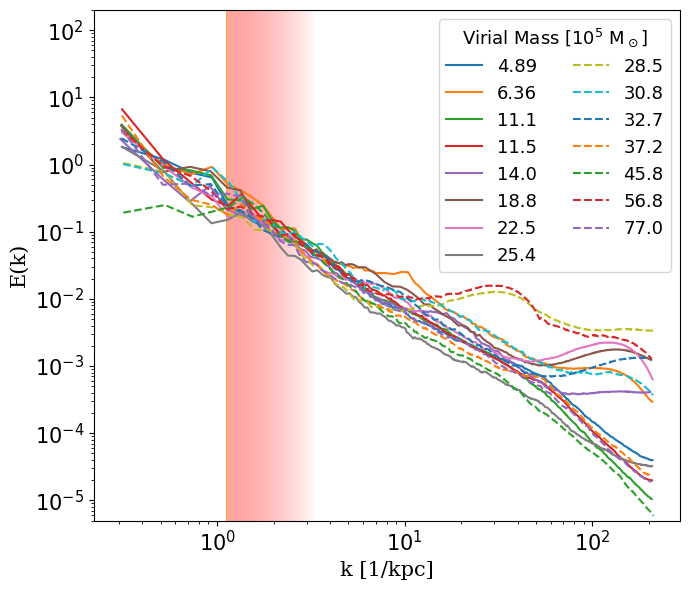

In [29]:
# For Ch3_5_turb3
# Record the mach_number curve in every valid model directory

font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

# Find all model directories ending with 'a'
models = [model for model in os.listdir('./') if (model[2] == '_') and model[-1] == 'a']
model_id = [int(model[10:15]) for model in models]

# halo_list= [ 0, 3, 5, 6, 7, 8, 10, 12, 13, 14]
halo_list = np.arange(15)
halo_id_list = [ f['Subhalo ID'][ind] for ind in halo_list ]
snapshot_ind_list = [ f['Last snapshot'][ind] for ind in halo_list ]
legend = []

k_ref = 0
plt.figure(figsize=(7, 6))
for ind, dir in enumerate(halo_id_list):

    dir_idx = np.where(model_id == dir)[0][0]
    dir = models[dir_idx]

    spectrum_file = os.path.join(dir + '/output/combined_spectrum.txt')
    # spectrum_file = os.path.join(dir + '/output/spectrum_008.txt')
    if os.path.exists(spectrum_file):
        data = np.loadtxt(spectrum_file)
        # k = data[:-2, 0] / (1/19 * 4.55e21 / 3.08e21)
        k = data[:-2, 0]
        E_k = data[:-2, 1]
        k_ref = E_k[0]

        # Apply special cases
        if ind == 8:
            E_k *= 0.5
        elif ind == 12:
            E_k *= 0.5
        elif ind == 7:
            E_k *= 2e3
        elif ind == 6: # Pink
            E_k *= 0.8

        if ind < 8:
            plt.plot( k, E_k )
        else:
            plt.plot( k, E_k, linestyle='--' )

    legend.append( int(f['Virial Mass'][halo_list[ind]] / 1e3) ) 

# Plot Kolmogorov slope for reference
E_k_ref = k_ref**(-5/3)
# plt.plot(k_ref, E_k_ref / E_k_ref[0] * 0.1, 'k--', label='Kolmogorov -5/3')

legend = np.array( legend ) /1e2 
for ind, val in enumerate(legend):
    if val > 10:
        legend[ind] = val * 100 // 10 / 10

plt.legend( legend, loc='upper right', title='Virial Mass [10$^5$ M$_\odot$]', fontsize=13, title_fontsize=13, ncol=2)
# plt.legend( legend, loc='lower left', title='Virial Mass [10$^5$ M$_\odot$]', fontsize=13, title_fontsize=14, ncol=2, framealpha = 1)
plt.xscale('log')
plt.yscale('log')
plt.ylim( 5e-6, 2e2 )

bin = 100
for i in range(bin):
    factor = (bin - i) / bin
    length = (1/0.3 - 1/0.9) / bin
    plt.axvspan(1/0.9, 1/0.9 + length * i, color='orange' , alpha = 0.005 )
plt.xlabel('k [1/kpc]'      , fontdict=font)
plt.ylabel('E(k)'           , fontdict=font)
plt.xticks( fontsize=15 )
plt.yticks( fontsize=15 )

# Label the Turuing Point Area

plt.tight_layout()
plt.show()

In [ ]:
# Find all model directories ending with 'a'
models = [model for model in os.listdir('./') if (model[2] == '_') and model[-1] == 'a']

plt.figure(figsize=(10, 7))
# There are two outputs of spectrum in the directory
# Combine these two datasets at the closest E(k) value
for model in models:
    spectrum_file = os.path.join(model, 'output', 'spectrum_008.txt')
    if os.path.exists(spectrum_file):
        data = np.loadtxt(spectrum_file)
        k = data[:, 0]
        E_k = data[:, 1]
        plt.plot(k, E_k, label=model)
    else:
        print(f"Spectrum file not found for {model}")

# Plot Kolmogorov slope for reference
k_ref = np.logspace(np.log10(1), np.log10(100), 100)
E_k_ref = k_ref**(-5/3)
plt.plot(k_ref, E_k_ref / E_k_ref[0] * 0.1, 'k--', label='Kolmogorov -5/3')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel('E(k)')
plt.title('Kolmogorov Spectrum for All Models')
plt.legend(fontsize=8, loc='best', ncol=2)
plt.tight_layout()
plt.show()